(25, 3)
        date         value  pib_norm_100
0 2024-12-31  1.722746e+12    100.000000
1 2023-12-31  1.620091e+12     94.041185
2 2022-12-31  1.446498e+12     83.964680
3 2021-12-31  1.461245e+12     84.820683
4 2020-12-31  1.289784e+12     74.867906


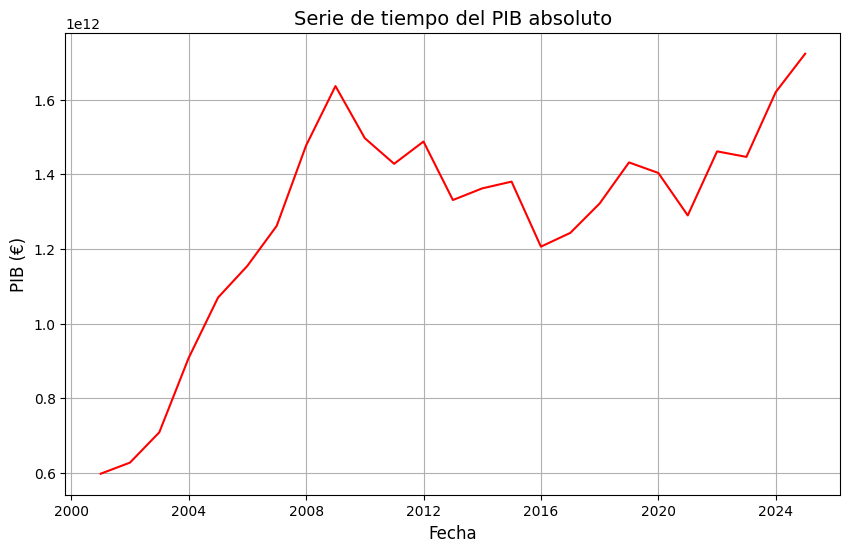

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar visualización en Jupyter
%matplotlib inline

# Cargar datos
df = pd.read_csv('C:\\Users\\ivanb\\OneDrive\\Desktop\\analisis_exploratorio\\data\\pib_esp.csv')

# Convertir fechas
df['date'] = pd.to_datetime(df['date'])

# Verificar datos
print(df.shape)
print(df.head())

# Graficar PIB absoluto
plt.figure(figsize=(10,6))
plt.plot(df['date'], df['value'], color='red')
plt.title('Serie de tiempo del PIB absoluto', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('PIB (€)', fontsize=12)
plt.grid(True)
plt.show()

In [18]:
from prophet import Prophet
import pandas as pd
import joblib
import os

# Cargar datos
df = pd.read_csv('C:/Users/ivanb/OneDrive/Desktop/analisis_exploratorio/data/pib_esp.csv')
df['date'] = pd.to_datetime(df['date'])

# Preparar datos para Prophet
df_prophet = df[['date', 'pib_norm_100']].rename(columns={'date': 'ds', 'pib_norm_100': 'y'})

# Crear y entrenar modelo
model = Prophet()
model.fit(df_prophet)

# Crear carpeta 'models' si no existe
os.makedirs('models', exist_ok=True)

# Guardar modelo
joblib.dump(model, 'models/prophet_pib.pkl')
print("✅ Modelo entrenado y guardado en 'models/prophet_pib.pkl'")


15:36:13 - cmdstanpy - INFO - Chain [1] start processing
15:36:14 - cmdstanpy - INFO - Chain [1] done processing


✅ Modelo entrenado y guardado en 'models/prophet_pib.pkl'


In [20]:
# Cargar modelo
model = joblib.load('models/prophet_pib.pkl')

# Crear fechas futuras (por ejemplo, 10 años más)
future = model.make_future_dataframe(periods=10, freq='YE')

# Predecir
forecast = model.predict(future)

# Ver resultados
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

           ds        yhat  yhat_lower  yhat_upper
25 2025-12-31   95.796047   80.761525  110.325802
26 2026-12-31   98.393441   83.442282  112.305264
27 2027-12-31  101.162555   85.941879  116.182822
28 2028-12-31  100.081463   85.948341  115.254675
29 2029-12-31  102.506022   86.928634  117.540928
30 2030-12-31  105.103417   89.395318  121.408890
31 2031-12-31  107.872530   92.765588  123.698893
32 2032-12-31  106.791439   92.132671  122.535922
33 2033-12-31  109.215998   94.359322  123.816887
34 2034-12-31  111.813392   96.174633  127.348731


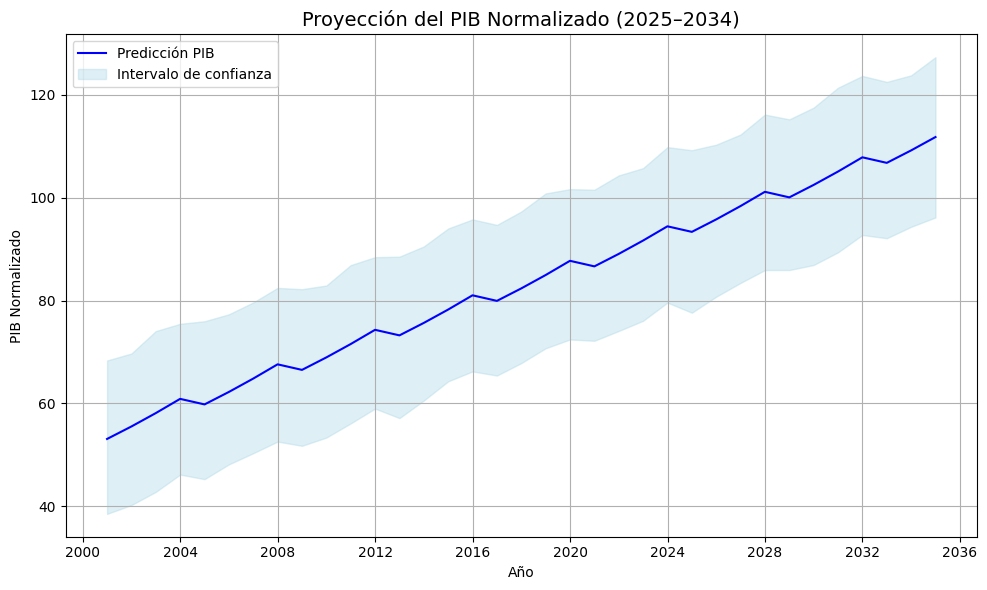

In [21]:
import matplotlib.pyplot as plt

# Graficar predicción con bandas de confianza
fig, ax = plt.subplots(figsize=(10, 6))

# Línea de predicción
ax.plot(forecast['ds'], forecast['yhat'], label='Predicción PIB', color='blue')

# Banda de confianza
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                color='lightblue', alpha=0.4, label='Intervalo de confianza')

# Estética
ax.set_title('Proyección del PIB Normalizado (2025–2034)', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('PIB Normalizado')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [30]:
df.loc[df['date'].dt.year == 2026, 'pib_norm_100'] *= 0.85  # caída del 15%

In [35]:
from prophet import Prophet

# Preparar datos para Prophet
df_prophet = df[['date', 'pib_norm_100']].rename(columns={'date': 'ds', 'pib_norm_100': 'y'})

# Crear y entrenar modelo
model_shock = Prophet()
model_shock.fit(df_prophet)

15:49:25 - cmdstanpy - INFO - Chain [1] start processing
15:49:25 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
future_shock = model_shock.make_future_dataframe(periods=10, freq='YE')
forecast_shock = model_shock.predict(future_shock)

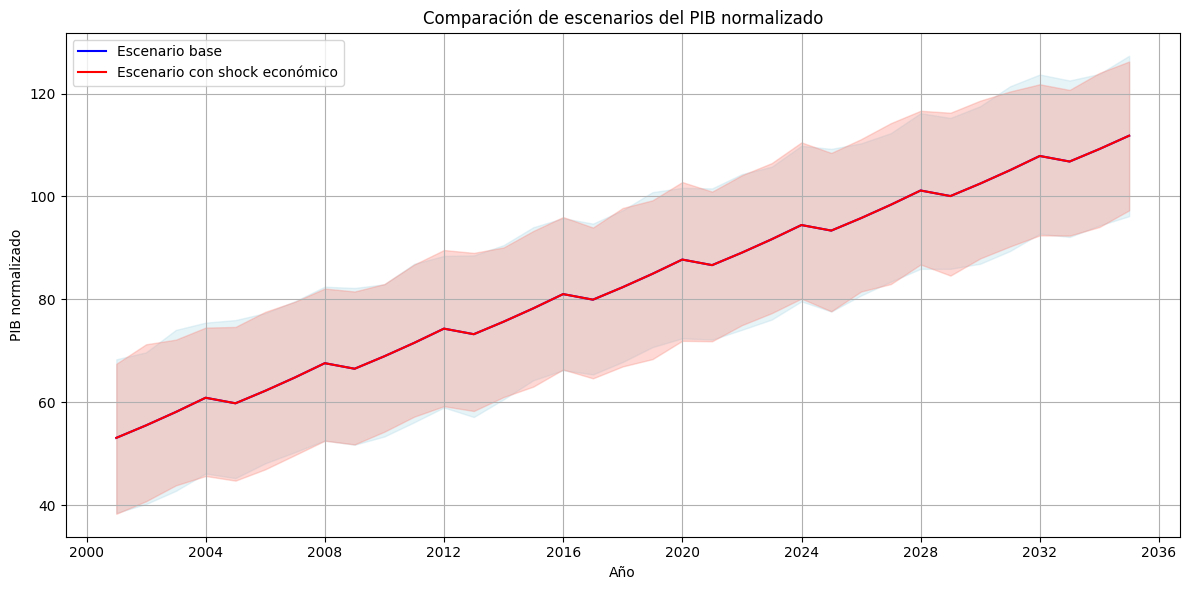

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Predicción original
plt.plot(forecast['ds'], forecast['yhat'], label='Escenario base', color='blue')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='lightblue', alpha=0.3)

# Predicción con shock
plt.plot(forecast_shock['ds'], forecast_shock['yhat'], label='Escenario con shock económico', color='red')
plt.fill_between(forecast_shock['ds'], forecast_shock['yhat_lower'], forecast_shock['yhat_upper'], color='salmon', alpha=0.3)

# Estética
plt.title('Comparación de escenarios del PIB normalizado')
plt.xlabel('Año')
plt.ylabel('PIB normalizado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()